In [1]:
from sklearn.datasets import make_regression
import numpy as np

In [2]:
X,y = make_regression(n_samples=4 , n_features=1 , n_informative=1 , n_targets=1, noise = 80 , random_state= 13)

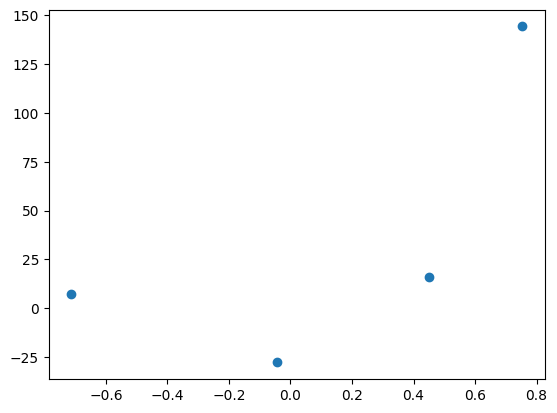

In [3]:
import matplotlib.pyplot as plt
plt.scatter(X,y)

In [4]:
from sklearn.linear_model import LinearRegression

In [5]:
reg = LinearRegression()
reg.fit(X,y)

LinearRegression()

In [6]:
reg.coef_

array([78.35063668])

In [7]:
reg.intercept_

np.float64(26.15963284313262)

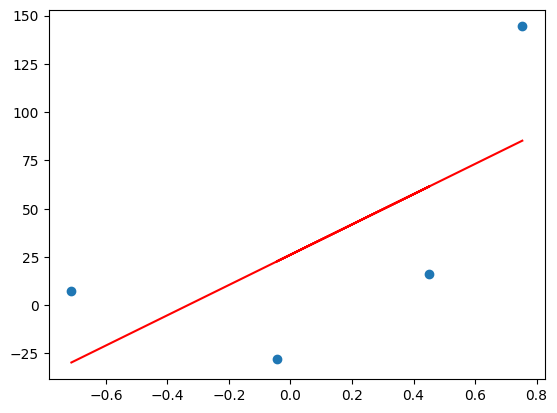

In [8]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red')

In [9]:
#now applying gradient descent for which the value of m is 78.35
#also assume the starting value of b is 0

y_pred = ((78.35*X) + 100).reshape(4)

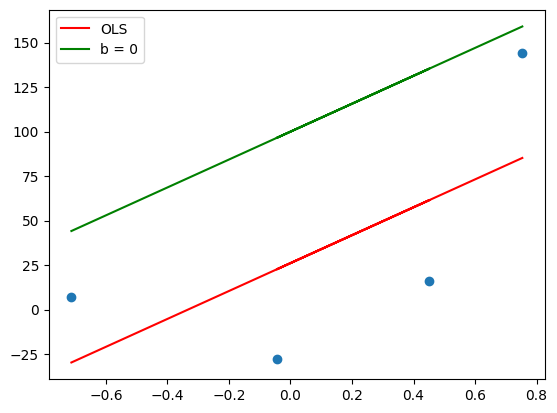

In [10]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label = 'OLS')
plt.plot(X,y_pred,color='green',label = 'b = 0')
plt.legend()
plt.show()

In [11]:
m = 78.35
b= 100

loss_slope = -2* np.sum(y-m*X.ravel() - b)
loss_slope

np.float64(590.7223659179078)

In [12]:
#taking the learning rate = 0.1
lr = 0.1

step_size = loss_slope*lr
step_size



np.float64(59.072236591790784)

In [13]:
#calculating the new intercept
b = b- step_size
b


np.float64(40.927763408209216)

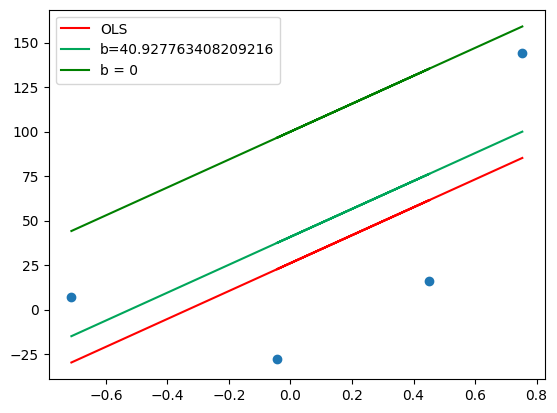

In [14]:
y_pred1 = ((78.35* X) + b).reshape(4)
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label = 'OLS')
plt.plot(X,y_pred1,color = '#00a65a',label = 'b={}'.format(b))
plt.plot(X,y_pred,color='green',label = 'b = 0')
plt.legend()
plt.show()

In [15]:
#iteration 2
loss_slope = -2 * np.sum(y-m*X.ravel() - b)
loss_slope

np.float64(118.14447318358157)

In [16]:
step_size = loss_slope*lr
step_size

np.float64(11.814447318358157)

In [17]:
b = b - step_size
b

np.float64(29.11331608985106)

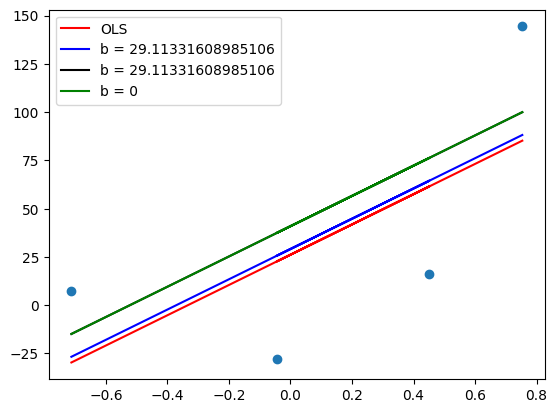

In [18]:
y_pred2 = ((78.35* X) + b).reshape(4)
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label = 'OLS')
plt.plot(X,y_pred2,color = 'blue',label = 'b = {}'.format(b))
plt.plot(X,y_pred1,color='black',label = 'b = {}'.format(b))
plt.plot(X,y_pred1,color='green',label = 'b = 0')
plt.legend()
plt.show()


In [19]:
#iteration 3
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(23.62889463671634)

In [20]:
step_size = loss_slope * lr
step_size

np.float64(2.362889463671634)

In [21]:
b = b - step_size
b

np.float64(26.750426626179426)

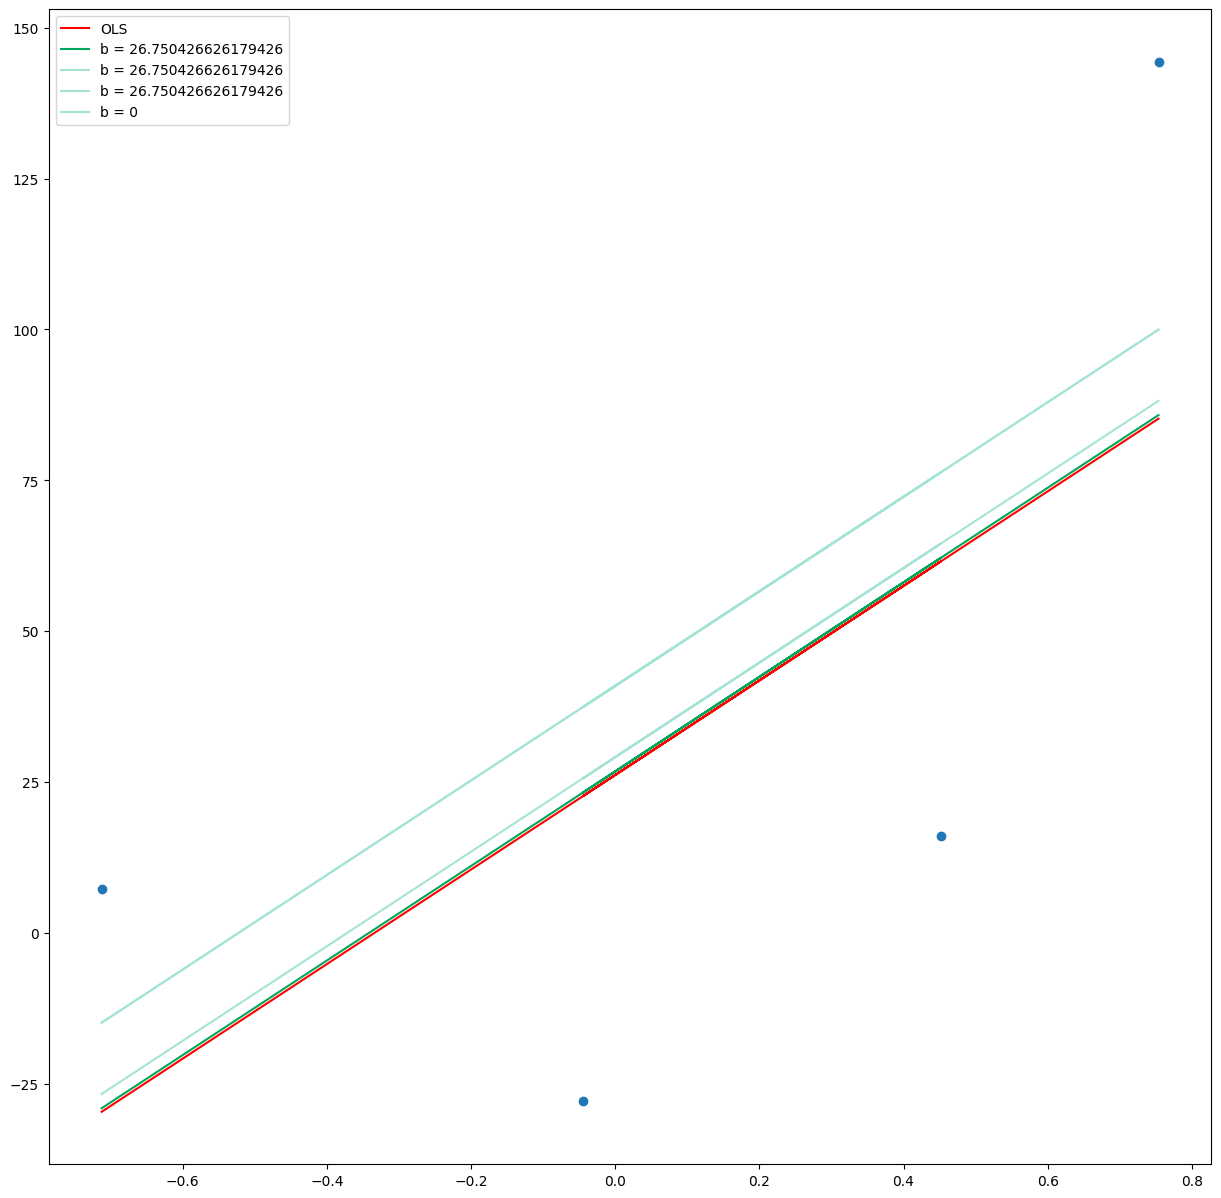

In [22]:
y_pred3 = ((78.35 * X) + b).reshape(4)

plt.figure(figsize = (15,15))
plt.scatter(X,y)
plt.plot(X , reg.predict(X) , color = 'red' , label = 'OLS')

plt.plot(X,y_pred3,color = '#00a65a',label = 'b = {}'.format(b))
plt.plot(X,y_pred2,color='#A3E4D7',label = 'b = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label = 'b = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label = 'b = 0')

plt.legend()
plt.show()


In [23]:
b = -100
m = 78.35
lr = 0.1

epochs = 10

for i in range(epochs) :
  loss_slope = -2 * np.sum(y - m*X.ravel() - b)
  b = b - (lr * loss_slope)

y_pred = m*X + b



In [24]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

In [25]:
X,y = make_regression(n_samples= 100 , n_features= 1 , n_informative=1 , n_targets=1 , noise = 20 , random_state= 13)

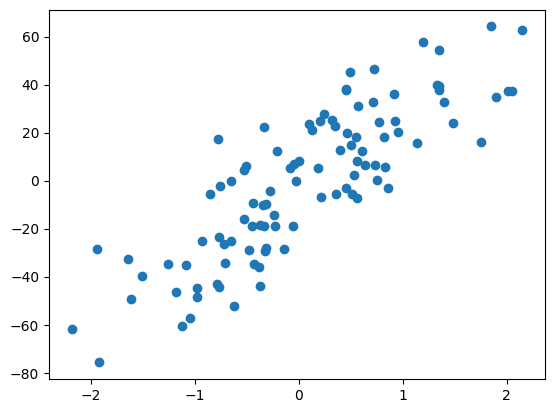

In [26]:
plt.scatter(X,y)

In [27]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state =2 )

In [28]:
from sklearn.linear_model import LinearRegression

In [29]:
lr = LinearRegression()

In [30]:
lr.fit(X_train,y_train)
print(lr.coef_)
print(lr.intercept_)

[28.12597332]
-2.2710144261783825


In [31]:
y_pred = lr.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.6345158782661012

In [32]:
class GDRegressor :
  def __init__(self,learning_rate,epochs):
    self.m = 100
    self.b = -120
    self.lr = learning_rate
    self.epochs = epochs

  def fit(self,X,y):
    for i in range(self.epochs):
      loss_slope_b = -2 * np.sum(y - self.m*X.ravel() - self.b)
      loss_slope_m = -2 * np.sum((y - self.m*X.ravel() - self.b)*X.ravel())
      self.b = self.b - (self.lr * loss_slope_b)
      self.m = self.m - (self.lr * loss_slope_m)
    print(self.m ,self.b)

  def predict(self,X):
    return self.m*X + self.b

In [33]:
gd = GDRegressor(0.001 , 50)

In [34]:
gd.fit(X_train,y_train)

28.159367347119066 -2.3004574196824854


In [35]:
gd.predict(X)

array([[-22.36092777],
       [-14.61020252],
       [-15.07783741],
       [ 24.53064978],
       [  4.39746882],
       [ 21.95071003],
       [ -9.15237073],
       [  2.90750354],
       [-22.60335208],
       [-14.40608727],
       [ 54.44688608],
       [  8.88560702],
       [  3.55106062],
       [ -8.84542293],
       [-23.94450805],
       [ 10.46020244],
       [ 15.71827044],
       [  7.82374456],
       [-47.78087586],
       [ 46.95708473],
       [-24.51788921],
       [-16.71707058],
       [-28.44179006],
       [ 58.2529665 ],
       [ -8.13929374],
       [-48.4562909 ],
       [-11.83573323],
       [-11.37125581],
       [-15.85557195],
       [-17.03243073],
       [ 18.02962184],
       [ 19.26711317],
       [ 10.46928178],
       [-37.82648268],
       [-63.88823983],
       [-35.68110113],
       [  3.82284374],
       [ 35.16042552],
       [-32.91480321],
       [ 13.53247651],
       [-44.90121876],
       [ -2.36773087],
       [-10.13254944],
       [ 10

In [36]:
y_pred = gd.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.6343842836315579

In [37]:
from sklearn.datasets import load_diabetes

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [38]:
X,y = load_diabetes(return_X_y=True)

In [39]:
print(X.shape)
print(y.shape)

(442, 10)
(442,)


In [40]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [41]:
reg = LinearRegression()
reg.fit(X_train,y_train)
print(reg.coef_)
print(reg.intercept_)

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
151.88331005254167


In [42]:
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.4399338661568968

In [44]:
class GDRegressor:
  def __init__(self,learning_rate = 0.01,epochs = 100):

    self.coef_ = None
    self.intercept_ = None
    self.lr = learning_rate
    self.epochs = epochs

  def fit(self,X_train,y_train):
    #init your coeffs
    self.intercept_ = 0
    self.coef_ = np.ones(X_train.shape[1])

    for i in range(self.epochs):
      #update all the coeffs and the intercept
      y_hat = np.dot(X)
      intercept_der = -2 * np.mean(y_train - y_hat)
      self.intercept_ = self.intercept_ - (self.lr * intercept_der)
    print(self.intercept_ , self.coef_)

  def predict(self,X_test):
    pass

In [45]:
gdr = GDRegressor()
gdr.fit(X_train,y_train)

130.52896930987225 [ 2.63772241  1.19060622  5.06046267  4.31375004  2.44715577  1.99246132
 -1.48838841  3.60218122  5.24193975  3.51394813]
